In [41]:
import os
import farsight as fs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import synth_reader as sr
from astropy.io import fits
from astropy.table import Table
from joblib import Parallel, delayed

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
from astropy.table import join

from sklearn.decomposition import PCA

import numpy as np
from matplotlib import pyplot as plt
import os
from astropy.table import Table
from astropy.cosmology import FlatwCDM
from getdist import plots, MCSamples
import zeus
from zeus import ChainManager
import numpy as np
import scipy.optimize as op
from multiprocessing import Pool




In [42]:
FADO = Table.read(fits.open('FadoGordonBest_Run.fits')[1])

In [43]:
np.sum(FADO['DESI_DR1'])

45

In [44]:
class Data_get:
    def __init__(self,data,outliers,select):
        self.data = data
        self.outliers = outliers
        self.data_clean = None
        self.select = select #Debe ser una lista de Tuplas
        self.set = None
        self.remove_outliers()
        self.set_selection()


    def remove_outliers(self):
        tmp_dataFrame = self.data
        for x in self.outliers:
            tmp_dataFrame = tmp_dataFrame[tmp_dataFrame['TAB5_INDEX']!=x]
        self.data_clean = tmp_dataFrame 

    def set_selection(self):
        tmp_dataFrame = self.data_clean
        for s in range(len(self.select)):
            if self.select[s][1] == '==':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]==self.select[s][2]]
            elif self.select[s][1] == '!=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]!=self.select[s][2]]
            elif self.select[s][1] == '>=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]>=self.select[s][2]]
            elif self.select[s][1] == '<=':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]<=self.select[s][2]]
            elif self.select[s][1] == '>':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]>self.select[s][2]]
            elif self.select[s][1] == '<':
                tmp_dataFrame = tmp_dataFrame[tmp_dataFrame[self.select[s][0]]<self.select[s][2]]
        self.set = tmp_dataFrame

    def figure_merit(self):
        x = np.array(self.set['ADEV'])
        y = np.array(self.set['chi2_red'])
        punto_ref = np.array([0, 1])
        distancias = np.sqrt((x - punto_ref[0])**2 + (y - punto_ref[1])**2)
        distancia_promedio = np.mean(distancias)

        return distancia_promedio


        
class Plotter(Data_get):
    def __init__(self,data,outliers,select):
        super().__init__(data,outliers,select)
        self.remove_outliers()
        self.set_selection()


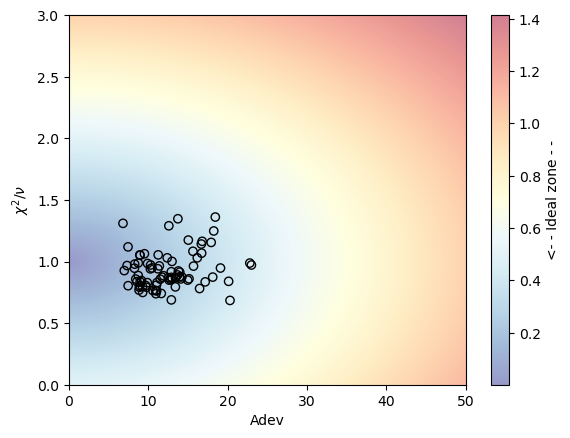

In [45]:
x = np.linspace(0, 50, 500)
y = np.linspace(0, 3, 500)
X, Y = np.meshgrid(x, y)
x_norm = (X - 0) / 50
y_norm = (Y - 1) / 2 
Z = np.sqrt(x_norm**2 + y_norm**2)
fig, ax = plt.subplots()
im = ax.imshow(Z, extent=[0, 50, 0, 3], origin='lower', cmap='RdYlBu_r', aspect='auto',alpha=0.5)

DATA = Data_get(FADO,[56],
                [('RED_LAW','==','Gordon et al. 2003 - SMC Bar'),#]).set
                 ('SDSS_SNR','>=',10),
                 ('ADEV','>=',0),('ADEV','<=',25),
                 ('chi2_red','>=',0.5),('chi2_red','<=',1.5)]).set

ax.scatter(DATA['ADEV'], DATA['chi2_red'],marker = 'o',facecolors='none', edgecolors='black')

ax.set_xlabel(r'Adev')
ax.set_ylabel(r'$\chi^{2}/\nu$')
plt.colorbar(im, label='<- - Ideal zone - -')


plt.show()

In [46]:
DATA['lgSFR'] = np.log10(DATA['SFR'])
DATA['lgsSFR'] = np.log10(DATA['sSFR'])
for col in DATA.colnames:
    if np.issubdtype(DATA[col].dtype, np.number):
        mask = (DATA[col] == -999.0) | (DATA[col] == 999.0)
        DATA[col][mask] = np.random.normal(loc=0.1,scale=0.1)


FADO.columns

<TableColumns names=('SDSS_PMF','TAB5_INDEX','NED_NAME','PLATE','MJD','FIBERID','RA','DEC','Z','DESI_DR1','SDSS_SNR','converge','time','l_0','f_0','f_u','chi2_val','chi2_dev','chi2_red','L_dst','I_l','F_l','S_l','Cb_L','Cf_l','z','z_err','BPT_flag','BPT_Class','lgNII_Ha','elgNII_Ha','lgOIII_Hb','elgNII_Hb','T_e','n_e','A_v','eA_v','A_neb','eA_neb','v_0','ev_0','v_d','ev_d','t_av_L','et_av_L','t_av_M','et_av_M','lgt_av_L','elgt_av_L','lgt_av_M','elgt_av_M','Z_av_L','eZ_av_L','Z_av_M','etZ_av_M','lg_Me','elg_Me','lg_Mp','elg_Mp','lg_MepAGB','elg_MepAGB','lg_MppAGB','elg_MppAGB','tL_l0','etL_l0','tL_l0oneGyr','etL_l0oneGyr','tL_l0fivGyr','etL_l0fivGyr','lg_QH','elg_QH','lg_QHeI','elg_QHeI','lg_QHeII','elg_QHeII','pre_FHa','epre_FHa','pre_EWHa','epre_EWHa','pre_FHb','epre_FHb','pre_EWHb','epre_EWHb','obs_FHa','eobs_FHa','obs_EWHa','eobs_EWHa','obs_FHb','eobs_FHb','obs_EWHb','eobs_EWHb','tau_HaL','etau_HaL','tau_HaLext','etau_HaLext','tau_pAGBL','etau_pAGBL','tau_pAGBLext','etau_pAGBLext','

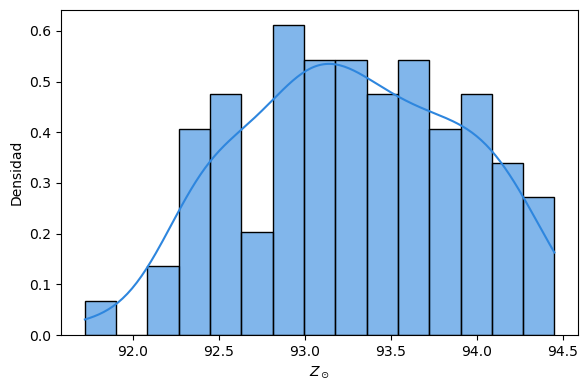

In [24]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(6,4))


var = DATA['lg_QH']

Z = np.array(var).byteswap().newbyteorder()


sns.histplot(
    Z,
    bins=15,
    kde=True,
    stat="density",
    color="#2E86DE",
    edgecolor="black",
    alpha=0.6,
    ax=ax
)

ax.set_xlabel(r'$Z_\odot$')
ax.set_ylabel('Densidad')

plt.tight_layout()
plt.show()

### MERGER DE TABLAS

In [47]:
tabla6_2014 = pd.read_csv('~/HIIGalaxies/Spectral_synthesis/Table6_art2014.csv')

In [48]:
def OH_to_Z(OH):
    return 10**(OH - 8.69)

tabla6_2014['Z_convOH'] = OH_to_Z(tabla6_2014['12+logO/H'])

TABLA6_astropy = Table.from_pandas(tabla6_2014)


In [49]:
tabla3_2014 = pd.read_csv('~/HIIGalaxies/Spectral_synthesis/Table3_art2014.csv')

TABLA3_astropy = Table.from_pandas(tabla3_2014)

In [50]:
merger_i = join(DATA, TABLA6_astropy, keys='TAB5_INDEX') # MERGER 1: Tabla 6 del articulo con los datos de FADO

merger_f = join(merger_i, TABLA3_astropy, keys='TAB5_INDEX') # MERGER 1: Tabla 3 del articulo con el merger anterior

In [51]:
# Calculos de proporciones de masas y demas.

burstAge_L = []
burstAge_M = []

Pop_5Myr  = []
Pop_10Myr = []
Pop_30Myr = []
Pop_100Myr = []




def nebular_fraction_at_lambda(wave, F_neb, F_star, lambda0=4861, window=20):
    mask = (wave > lambda0 - window) & (wave < lambda0 + window)

    neb = np.nanmedian(F_neb[mask])
    star = np.nanmedian(F_star[mask])

    return neb / (neb + star)

def nebular_fraction_integrated(wave, F_neb, F_star, lmin=3800, lmax=7000):
    mask = (wave >= lmin) & (wave <= lmax)

    neb_int = np.trapz(F_neb[mask], wave[mask])
    total_int = np.trapz((F_neb[mask] + F_star[mask]), wave[mask])

    return neb_int / total_int


fneb_4020_list = []
fneb_4861_list = []
fneb_opt_list = []



for x in range(len(merger_f)):

    obj = merger_f['TAB5_INDEX'][x]
    obj =str(obj)

    if len(obj)!=3:
        if len(obj) == 2:
            obj = '0' + obj
        else:
            obj = '00' + obj

    spec = fs.Nebulix(home = os.path.expanduser('~') +'/HIIGalaxies/FADO/output_4020/',
               file = f'{obj}GOR1.MILES150_1D.fits', 
               distance = merger_f[merger_f['TAB5_INDEX']>=int(obj)]['Z'][0])
    
    SSPs = spec.population_vector.copy()

    # Convertir masa corregida a unidades físicas
    SSPs['Mcor_jMo'] = (SSPs['Mcor_j'] / 100.0) * 10**spec.fado_ensemble['lg_Mp']

    # Máscara de población joven (t < 10 Myr)
    you_mask = SSPs['logage_j'] <= 7.0

    # Extraer columnas (astropy Table soporta esto directamente)
    x = SSPs['x_j'][you_mask]          # fracción de luz (%)
    m = SSPs['Mcor_jMo'][you_mask]     # masa
    logt = SSPs['logage_j'][you_mask]  # log edad

    # (Opcional) convertir % a fracción
    x = x / 100.0

    # Inicializar valores por defecto
    Io_by_L = np.nan
    Io_by_M = np.nan

    # Promedio ponderado por luz
    if np.sum(x) > 0:
        Io_by_L = np.sum(x * logt) / np.sum(x)

    # Promedio ponderado por masa
    if np.sum(m) > 0:
        Io_by_M = np.sum(m * logt) / np.sum(m)

    # Guardar resultados
    burstAge_L.append(Io_by_L)
    burstAge_M.append(Io_by_M)


    wave = spec.spectrum_bestfit['Lambda']
    F_star = spec.spectrum_bestfit['Flux_ste']
    F_total = spec.spectrum_bestfit['Flux_syn']

    F_neb = F_total - F_star
    F_neb = np.where(F_neb > 0, F_neb, 0)

    fneb_4020 = nebular_fraction_at_lambda(
        wave, F_neb, F_star, lambda0=4020, window=20
    )

    fneb_4861 = nebular_fraction_at_lambda(
        wave, F_neb, F_star, lambda0=4861, window=20
    )

    fneb_opt = nebular_fraction_integrated(
        wave, F_neb, F_star, lmin=3800, lmax=7000
    )

    fneb_4020_list.append(fneb_4020)
    fneb_4861_list.append(fneb_4861)
    fneb_opt_list.append(fneb_opt)

    x_5Myr  = np.sum(SSPs['x_j'][SSPs['logage_j'] <= np.log10(5e6)])
    x_10Myr = np.sum(SSPs['x_j'][SSPs['logage_j'] <= 7.0])
    x_30Myr = np.sum(SSPs['x_j'][SSPs['logage_j'] <= np.log10(3e7)])
    x_100Myr = np.sum(SSPs['x_j'][SSPs['logage_j'] <= 8.0])

    Pop_5Myr.append(x_5Myr)
    Pop_10Myr.append(x_10Myr)
    Pop_30Myr.append(x_30Myr)
    Pop_100Myr.append(x_100Myr)



merger_f['burstAge_L'] = np.array(burstAge_L)
merger_f['burstAge_M'] = np.array(burstAge_M)

merger_f['fneb_4020'] = np.array(fneb_4020_list)
merger_f['fneb_4861'] = np.array(fneb_4861_list)
merger_f['fneb_opt'] = np.array(fneb_opt_list)

merger_f['Pop_5Myr'] = np.array(Pop_5Myr)
merger_f['Pop_10Myr'] = np.array(Pop_10Myr)
merger_f['Pop_30Myr'] = np.array(Pop_30Myr)
merger_f['Pop_100Myr'] = np.array(Pop_100Myr)


In [52]:
merger_f['log_EWHb'] = np.log10(merger_f['EW(Hb)'])

In [64]:
merger_f.columns

<TableColumns names=('SDSS_PMF','TAB5_INDEX','NED_NAME','PLATE','MJD','FIBERID','RA','DEC','Z','DESI_DR1','SDSS_SNR','converge','time','l_0','f_0','f_u','chi2_val','chi2_dev','chi2_red','L_dst','I_l','F_l','S_l','Cb_L','Cf_l','z','z_err','BPT_flag','BPT_Class','lgNII_Ha','elgNII_Ha','lgOIII_Hb','elgNII_Hb','T_e','n_e','A_v','eA_v','A_neb','eA_neb','v_0','ev_0','v_d','ev_d','t_av_L','et_av_L','t_av_M','et_av_M','lgt_av_L','elgt_av_L','lgt_av_M','elgt_av_M','Z_av_L','eZ_av_L','Z_av_M','etZ_av_M','lg_Me','elg_Me','lg_Mp','elg_Mp','lg_MepAGB','elg_MepAGB','lg_MppAGB','elg_MppAGB','tL_l0','etL_l0','tL_l0oneGyr','etL_l0oneGyr','tL_l0fivGyr','etL_l0fivGyr','lg_QH','elg_QH','lg_QHeI','elg_QHeI','lg_QHeII','elg_QHeII','pre_FHa','epre_FHa','pre_EWHa','epre_EWHa','pre_FHb','epre_FHb','pre_EWHb','epre_EWHb','obs_FHa','eobs_FHa','obs_EWHa','eobs_EWHa','obs_FHb','eobs_FHb','obs_EWHb','eobs_EWHb','tau_HaL','etau_HaL','tau_HaLext','etau_HaLext','tau_pAGBL','etau_pAGBL','tau_pAGBLext','etau_pAGBLext','

Text(0, 0.5, 'fneb_opt')

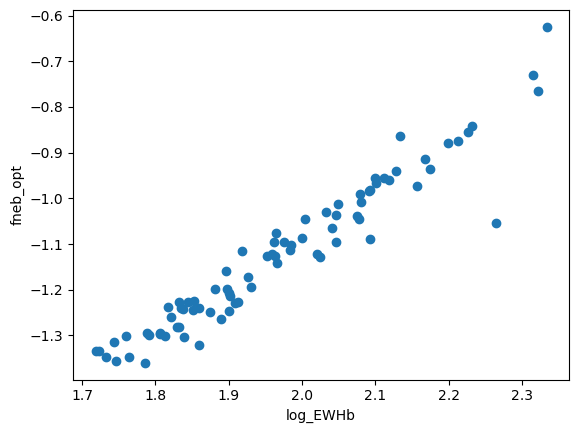

In [98]:
plt.scatter(merger_f['log_EWHb'],np.log10(merger_f['fneb_opt'])) #Aqui voy a plotear correlaciones entre cosas.
plt.xlabel('log_EWHb')
plt.ylabel('fneb_opt')
#plt.title('Mp vs Mdyn,ion,cl')

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x791ebb136660>
Traceback (most recent call last):
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^

Medias:
 [[9.87646933 0.33084599]
 [7.45824139 0.6992826 ]]
Pesos: [0.41464628 0.58535372]


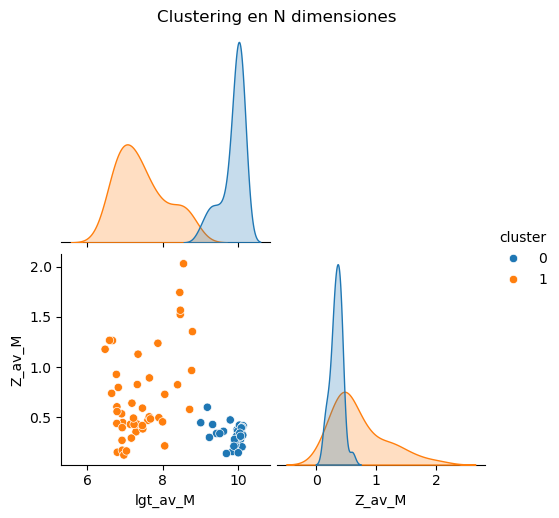

In [90]:
# ===== DEFINE TUS VARIABLES =====
cols = [
    'lgt_av_M',
    'Z_av_M',
    #'lg_Mp',
    #'logSFR',
    #'lg_MppAGB',
    #burstAge_M',
    #'lg_QH'
]

# ===== EXTRAER =====
#X = np.column_stack([np.asarray(DATA[c]).astype(float) for c in cols])
X = np.column_stack([np.asarray(merger_f[c]).astype(float) for c in cols])

# ===== LIMPIEZA =====
mask = np.all(np.isfinite(X), axis=1)
X = X[mask]


k = 2

gmm = GaussianMixture(n_components=k, random_state=42)
gmm.fit(X)

labels = gmm.predict(X)
proba  = gmm.predict_proba(X)

means = gmm.means_
covs  = gmm.covariances_
weights = gmm.weights_

print("Medias:\n", means)
print("Pesos:", weights)

df = pd.DataFrame(X, columns=cols)
df['cluster'] = labels

sns.pairplot(
    df,
    vars=cols,
    hue='cluster',
    palette='tab10',
    corner=True
)

plt.suptitle('Clustering en N dimensiones', y=1.02)
plt.show()

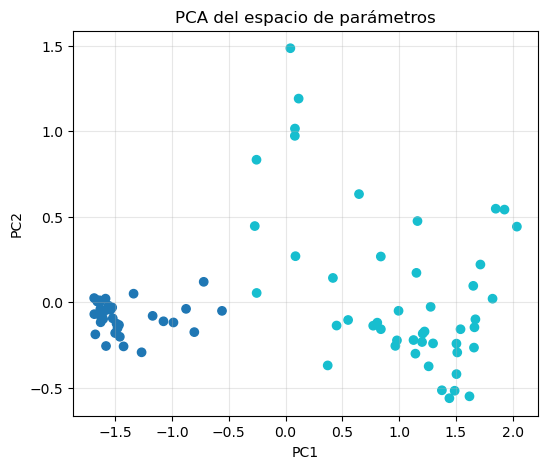

In [91]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA del espacio de parámetros')

plt.grid(alpha=0.3)
plt.show()

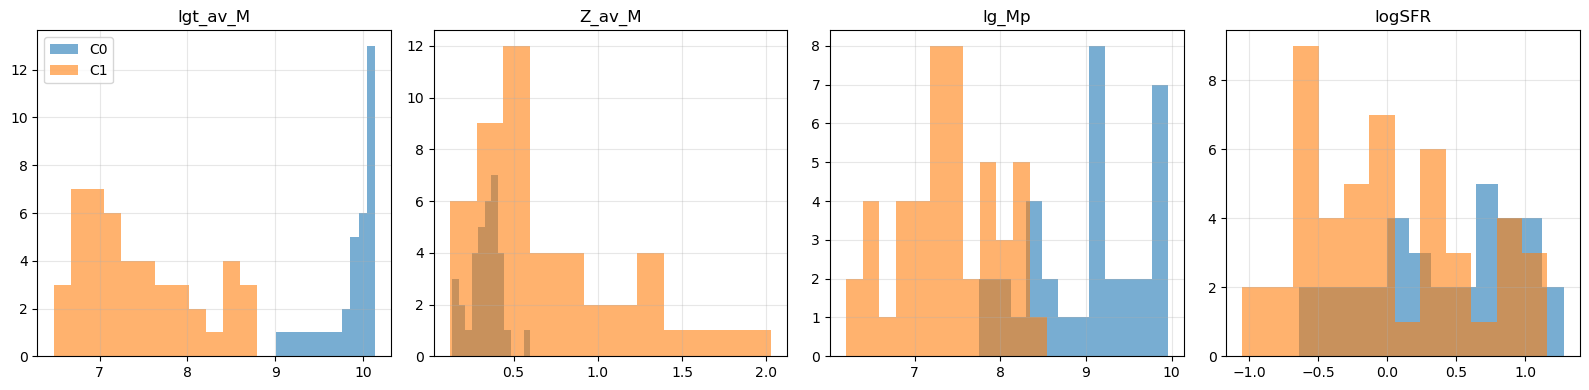

In [82]:
fig, axes = plt.subplots(1, len(cols), figsize=(4*len(cols),4))

for i, col in enumerate(cols):
    for c in range(k):
        axes[i].hist(X[labels==c, i], bins=12, alpha=0.6, label=f'C{c}')
    
    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()

In [17]:
for i, col in enumerate(cols):
    print(f"\n{col}")
    for c in range(k):
        print(f"Cluster {c}: mean =", np.mean(X[labels==c, i]))


lgt_av_M
Cluster 0: mean = 9.834685714285714
Cluster 1: mean = 7.415717391304346

Z_av_M
Cluster 0: mean = 0.34036
Cluster 1: mean = 0.7033663043478261

lg_Mp
Cluster 0: mean = 9.032428571428571
Cluster 1: mean = 7.366630434782608

burstAge_M
Cluster 0: mean = 6.632444395337786
Cluster 1: mean = 6.703667806542438

lg_QH
Cluster 0: mean = 93.46171428571428
Cluster 1: mean = 93.12695652173916


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x78e74ad219e0>
Traceback (most recent call last):
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^

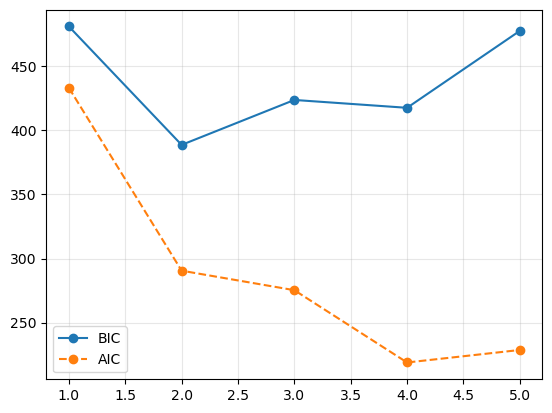

In [18]:
ks = range(1,6)
bics, aics = [], []

for k_test in ks:
    g = GaussianMixture(n_components=k_test, random_state=42).fit(X)
    bics.append(g.bic(X))
    aics.append(g.aic(X))

plt.plot(ks, bics, 'o-', label='BIC')
plt.plot(ks, aics, 'o--', label='AIC')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

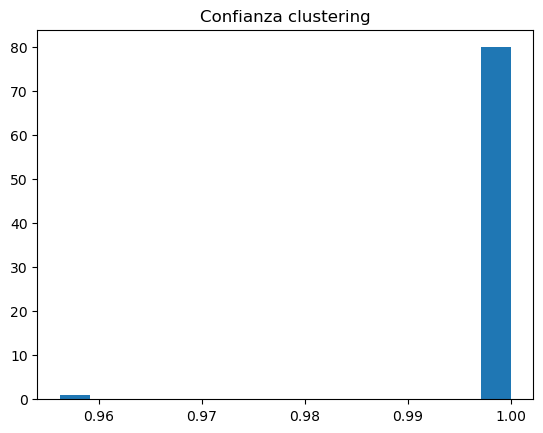

In [19]:
plt.hist(proba.max(axis=1), bins=15)
plt.title('Confianza clustering')
plt.show()

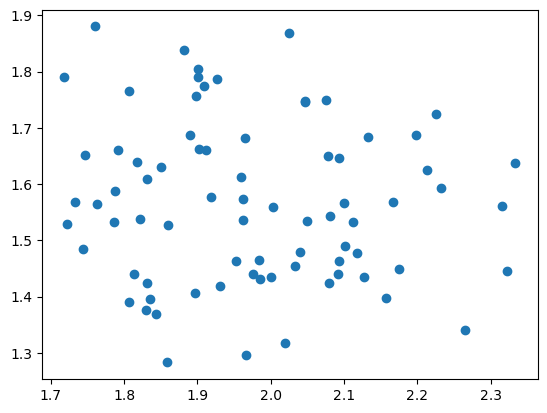

In [ ]:
'Name','F(Hb)DR7','Err_F(Hb)DR7','F(Hb)LSGF','Err_F(Hb)LSGFit','F(Hb)LSI','Err_F(Hb)LSI','F([OIII]l4959)LSGF','Err_F([OIII]l4959)LSGF','F([OIII]l5007)LSGF','Err_F([OIII]l5007)LSGF','EW(Hb)','Err_EW(Hb)','Inst.'

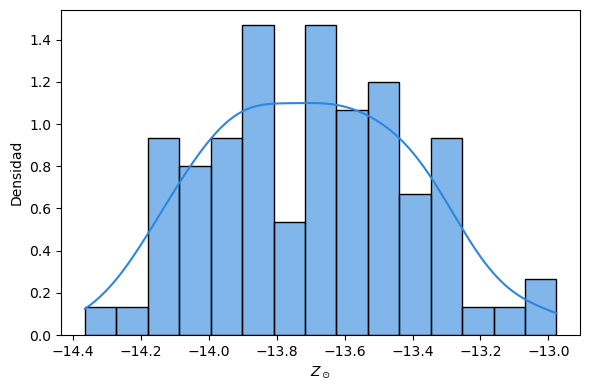

In [21]:
fig, ax = plt.subplots(figsize=(6,4)) # Este lo voy a dejar para ver como se ven los datos en histogramas.


var = np.log10(merger_f['F(Hb)LSGF']*1e-16)

Z = np.array(var)

sns.histplot(
    Z,
    bins=15,
    kde=True,
    stat="density",
    color="#2E86DE",
    edgecolor="black",
    alpha=0.6,
    ax=ax
)

ax.set_xlabel(r'$Z_\odot$')
ax.set_ylabel('Densidad')

plt.tight_layout()
plt.show()

/tmp/ipykernel_22890/2003474577.py:40: RuntimeWarning: divide by zero encountered in log10
  merged['Mass_quoI'] = np.log10(merged['Mass_int']) / merged['lg_Mp']
/tmp/ipykernel_22890/2003474577.py:41: RuntimeWarning: divide by zero encountered in log10
  merged['Mass_quoO'] = np.log10(merged['Mass_old']) / merged['lg_Mp']


In [84]:
merger_f.columns

<TableColumns names=('SDSS_PMF','TAB5_INDEX','NED_NAME','PLATE','MJD','FIBERID','RA','DEC','Z','DESI_DR1','SDSS_SNR','converge','time','l_0','f_0','f_u','chi2_val','chi2_dev','chi2_red','L_dst','I_l','F_l','S_l','Cb_L','Cf_l','z','z_err','BPT_flag','BPT_Class','lgNII_Ha','elgNII_Ha','lgOIII_Hb','elgNII_Hb','T_e','n_e','A_v','eA_v','A_neb','eA_neb','v_0','ev_0','v_d','ev_d','t_av_L','et_av_L','t_av_M','et_av_M','lgt_av_L','elgt_av_L','lgt_av_M','elgt_av_M','Z_av_L','eZ_av_L','Z_av_M','etZ_av_M','lg_Me','elg_Me','lg_Mp','elg_Mp','lg_MepAGB','elg_MepAGB','lg_MppAGB','elg_MppAGB','tL_l0','etL_l0','tL_l0oneGyr','etL_l0oneGyr','tL_l0fivGyr','etL_l0fivGyr','lg_QH','elg_QH','lg_QHeI','elg_QHeI','lg_QHeII','elg_QHeII','pre_FHa','epre_FHa','pre_EWHa','epre_EWHa','pre_FHb','epre_FHb','pre_EWHb','epre_EWHb','obs_FHa','eobs_FHa','obs_EWHa','eobs_EWHa','obs_FHb','eobs_FHb','obs_EWHb','eobs_EWHb','tau_HaL','etau_HaL','tau_HaLext','etau_HaLext','tau_pAGBL','etau_pAGBL','tau_pAGBLext','etau_pAGBLext','

In [ ]:
cols = [
    'lgt_av_M',
    'Z_av_M',
    'lg_Mp',
    'logL(Hb)',
    'log_sigma(Hb)',
    'log_sigma([OIII])',
    'lg_QH',
    'log_EWHb','burstAge_L','burstAge_M','fneb_4020','fneb_opt','Pop_5Myr','Pop_10Myr','Pop_30Myr','Pop_100Myr'
]

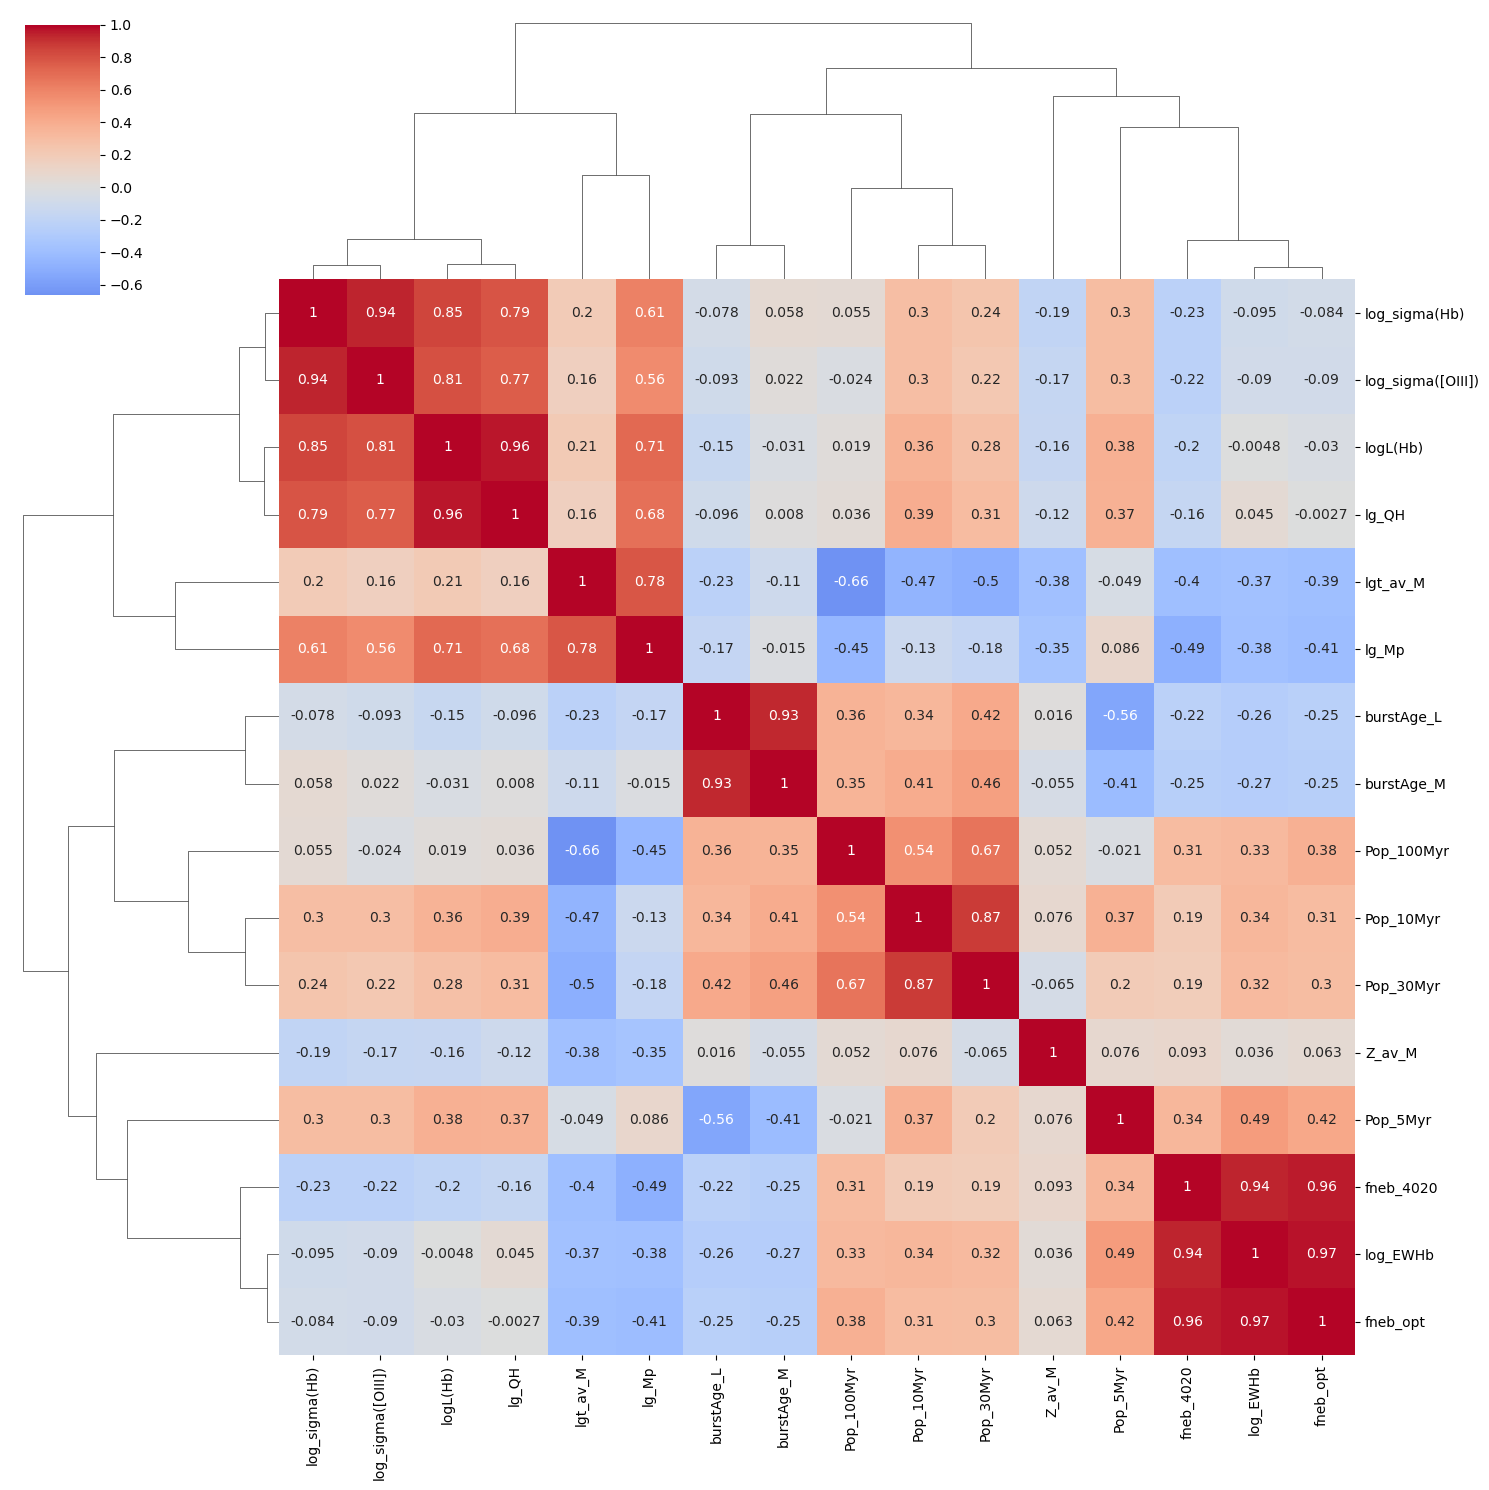

In [89]:
df = merger_f.to_pandas()   # o tu tabla ya mergeada

df = df[cols].apply(pd.to_numeric, errors='coerce')
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

corr = df.corr(method='spearman') 

sns.clustermap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    figsize=(15,15)
)


In [24]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0 = theta

    Om = 0.3
    w0 = -1.0

    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=w0)
    ixH = np.where(z<10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2*W)
    llq = -0.5*xsq
    return (llq, xsq, R, Mum)

In [25]:
def lnprior(theta):
    alpha, beta, h0 = theta
    if (0.0 <= beta <= 10.0 and 20.0 <= alpha <= 40.0 and 0.5 <= h0 <= 1.0):
        return 0.0
    return -np.inf

In [26]:
def lnpost(theta, x, y, z, xerr, yerr, zerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr)[0]

In [32]:
alpha_ml, beta_ml, h0_ml = 33.2169717140405, 5.046006556006849, 0.7156989221484847



# ===== DEFINE TUS VARIABLES =====
cols = [
    'log_sigma(Hb)',
    'F(Hb)LSGF',
    'z_c',
    'log_sigma(Hb)Err',
    'Err_F(Hb)LSGF',
    'z_cErr'
]

# ===== EXTRAER SUBTABLA =====
subtab = merger_f[cols]

# ===== CONSTRUIR MASCARA GLOBAL =====
mask = np.ones(len(subtab), dtype=bool)

for c in cols:
    mask &= np.isfinite(np.asarray(subtab[c]).astype(float))

# ===== APLICAR MASCARA =====
clean_tab = subtab[mask]

# ===== CONVERTIR A NUMPY ARRAY =====
X = np.column_stack([np.asarray(clean_tab[c]).astype(float) for c in cols])

# ===== DEFINIR VARIABLES =====
vx = X[:, 0]
vy = np.log10(X[:, 1] * 1e-16)
vz = X[:, 2]

vxErr = X[:, 3]
vyErr = np.log10(X[:, 4] * 1e-16)
vzErr = X[:, 5] 


nsteps = 1000
ndim, nwalkers = 3, 10
start = [[alpha_ml, beta_ml, h0_ml] + 1e-5*np.random.randn(ndim)
       for i in range(nwalkers)]

#with Pool() as pool:
sampler = zeus.EnsembleSampler(nwalkers, ndim, lnpost,
                                 args=(vx, vy, vz, vxErr, vyErr, vzErr)) # Estos son L(Hb), sigma y z
sampler.run_mcmc(start, nsteps)

sampler.summary

Initialising ensemble of 10 walkers...


Sampling progress :   0%|          | 0/1000 [10:06<?, ?it/s]


zeus: Exception while calling your likelihood function:
  params: [33.11174379  5.03540599  0.72851726]
  args: (array([1.377, 1.463, 1.538, 1.577, 1.454, 1.529, 1.527, 1.283, 1.369,
       1.625, 1.39 , 1.419, 1.484, 1.791, 1.463, 1.48 , 1.565, 1.588,
       1.532, 1.649, 1.688, 1.637, 1.652, 1.49 , 1.747, 1.449, 1.406,
       1.725, 1.766, 1.646, 1.566, 1.535, 1.477, 1.441, 1.787, 1.536,
       1.434, 1.44 , 1.75 , 1.746, 1.296, 1.425, 1.532, 1.839, 1.681,
       1.612, 1.774, 1.56 , 1.791, 1.63 , 1.593, 1.446, 1.639, 1.561,
       1.544, 1.569, 1.66 , 1.396, 1.434, 1.88 , 1.465, 1.868, 1.431,
       1.424, 1.609, 1.683, 1.688, 1.34 , 1.397, 1.441, 1.757, 1.662,
       1.66 , 1.318, 1.568, 1.805, 1.573]), array([-13.635449  , -13.81360878, -13.39008559, -13.3400838 ,
       -13.93070199, -14.17587417, -14.14569396, -14.0893756 ,
       -13.93442029, -13.81079051, -13.69336056, -14.13194364,
       -13.90101036, -13.41307529, -13.45345734, -13.93255716,
       -13.9625735 , -13.545307

Traceback (most recent call last):
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/zeus/fwrapper.py", line 24, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_9099/3770585977.py", line 5, in lnpost
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr)[0]
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_9099/2623516964.py", line 7, in lnlike
    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=w0)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<string>", line 12, in __init__
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/astropy/cosmology/_src/flrw/w0cdm.py", line 303, in __post_init__
    super().__post_init__()
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/astropy/cosmology/_src/flrw/base.py", line 1562, in __post_init__
    super().__post_init__()
  File "/home/holman/miniconda3/envs/cosmos/lib

KeyboardInterrupt: 

In [31]:
DaTa[0]

array([1.377e+00, 2.315e+02, 2.203e-02, 3.900e-02, 2.820e+01, 7.800e-06])

In [ ]:
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain()[:,:,n], alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
chain = sampler.get_chain(flat=True, discard=nsteps//4, thin=1)

In [ ]:
parameters = [r"\alpha", r"\beta", r"h"]

%matplotlib inline
tag = 'GDplot'
path = dpath+'results/GDplot.pdf'
GDsamples = MCSamples(samples=chain, names=parameters,
                          labels=parameters, name_tag=tag #,
                          # ranges={r"\Omega_m":[0.0, None]}
                          )

g = plots.getSubplotPlotter() #width_inch=4
g.settings.num_plot_contours = 2
g.triangle_plot(GDsamples, filled=True, title_limit=1,
            contour_colors=['crimson']
            # , param_limits={r"\alpha":[32.8, 33.7]
                        # , r"\beta":[4.7, 5.35]
                        # , r"h":[0.6, 0.85]
                        # , r"\Omega_m":[0.0, 0.52]
                        # , r"w_0":[-2.1, -0.2]
                        # }
            )
g.export(path)

In [ ]:
t = GDsamples.getTable(limit=1).tableTex()
theta = GDsamples.getMeans()

# Print parameter values
print('parameter values:')
for name, col in zip(parameters, chain.transpose()):
  print('%15s : %.3f +- %.3f' % (name, col.mean(), col.std()))

print(t)

In [100]:
def lnlike(theta, x, y, z, xerr, yerr, zerr, extra_vars=None, extra_errs=None):
    # theta: [alpha, beta, h0, gamma1, gamma2, ..., eps_int]
    alpha, beta, h0 = theta[0], theta[1], theta[2]
    eps_int = theta[-1] # El scatter intrínseco es siempre el último
    
    # Manejo de parámetros adicionales (gamma * Variable)
    n_extra = 0
    extra_contribution = 0.0
    extra_error_sq = 0.0
    
    if extra_vars is not None:
        n_extra = len(extra_vars)
        gammas = theta[3:3+n_extra]
        for i in range(n_extra):
            extra_contribution += gammas[i] * extra_vars[i]
            # Propagación de error para las variables adicionales
            if extra_errs is not None:
                extra_error_sq += (gammas[i] * extra_errs[i])**2

    # Cosmología teórica
    cosmo = FlatwCDM(H0=h0*100, Om0=0.3, w0=-1.0)
    
    # Módulo de distancia teórico (Mum)
    # Evitamos log de valores no físicos
    dist = cosmo.luminosity_distance(z).value
    Mum = 5.0 * np.log10(dist) + 25.0
    MumErr = (5.0 / np.log(10.0)) * (zerr / z)

    # Módulo de distancia observacional (Mu) con Plano Fundamental
    # Mu = 2.5 * (beta*x + alpha + gamma1*Z + ...) - 2.5*y - 100.195
    Mu = 2.5 * (beta * x + alpha + extra_contribution) - 2.5 * y - 100.195
    
    # Varianza efectiva: errores de medición + scatter intrínseco (eps_int)
    # eps_int se suma en cuadratura a los errores de Mu
    MuErr_sq = (2.5**2) * (yerr**2 + (beta**2 * xerr**2) + extra_error_sq)
    
    # Sigma total (incluye el scatter intrínseco que queremos medir)
    sigma_total_sq = MuErr_sq + MumErr**2 + eps_int**2

    # Likelihood logarítmica
    R = (Mu - Mum)
    llq = -0.5 * np.sum((R**2 / sigma_total_sq) + np.log(2 * np.pi * sigma_total_sq))
    
    return llq

def lnprior(theta, n_params):
    # n_params es el número total de elementos en theta
    alpha, beta, h0 = theta[0], theta[1], theta[2]
    eps_int = theta[-1]
    
    # Límites básicos
    if not (20.0 <= alpha <= 40.0 and 0.0 <= beta <= 10.0 and 0.5 <= h0 <= 1.0):
        return -np.inf
    
    # El scatter intrínseco DEBE ser positivo
    if not (0.0 <= eps_int <= 2.0):
        return -np.inf
    
    # Priors para gammas (pueden ser anchos)
    gammas = theta[3:-1]
    for g in gammas:
        if not (-5.0 <= g <= 5.0):
            return -np.inf
            
    return 0.0

def lnpost(theta, x, y, z, xerr, yerr, zerr, extra_vars, extra_errs):
    lp = lnprior(theta, len(theta))
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr, extra_vars, extra_errs)

In [ ]:
merger_f['']

<TableColumns names=('SDSS_PMF','TAB5_INDEX','NED_NAME','PLATE','MJD','FIBERID','RA','DEC','Z','DESI_DR1','SDSS_SNR','converge','time','l_0','f_0','f_u','chi2_val','chi2_dev','chi2_red','L_dst','I_l','F_l','S_l','Cb_L','Cf_l','z','z_err','BPT_flag','BPT_Class','lgNII_Ha','elgNII_Ha','lgOIII_Hb','elgNII_Hb','T_e','n_e','A_v','eA_v','A_neb','eA_neb','v_0','ev_0','v_d','ev_d','t_av_L','et_av_L','t_av_M','et_av_M','lgt_av_L','elgt_av_L','lgt_av_M','elgt_av_M','Z_av_L','eZ_av_L','Z_av_M','etZ_av_M','lg_Me','elg_Me','lg_Mp','elg_Mp','lg_MepAGB','elg_MepAGB','lg_MppAGB','elg_MppAGB','tL_l0','etL_l0','tL_l0oneGyr','etL_l0oneGyr','tL_l0fivGyr','etL_l0fivGyr','lg_QH','elg_QH','lg_QHeI','elg_QHeI','lg_QHeII','elg_QHeII','pre_FHa','epre_FHa','pre_EWHa','epre_EWHa','pre_FHb','epre_FHb','pre_EWHb','epre_EWHb','obs_FHa','eobs_FHa','obs_EWHa','eobs_EWHa','obs_FHb','eobs_FHb','obs_EWHb','eobs_EWHb','tau_HaL','etau_HaL','tau_HaLext','etau_HaLext','tau_pAGBL','etau_pAGBL','tau_pAGBLext','etau_pAGBLext','

In [107]:

vx, vy, vz = merger_f['log_sigma(Hb)'], merger_f['logL(Hb)'], merger_f['z_c'] 
vxErr, vyErr, vzErr = merger_f['log_sigma(Hb)Err'], merger_f['logL(Hb)Err'], merger_f['z_cErr'] 



# Ejemplo: quieres incluir Z (metalicidad) y EW
extra_data = [merger_f['logSFR'], merger_f['logM_dyn']]
extra_errors = [merger_f['logSFRErr'], merger_f['logM_dynErr']]

extra_data, extra_errors = None,None

#n_extra = len(extra_data)
ndim = 3 + 1 #+ n_extra + 1 # alpha, beta, h0 + gammas + eps_int
nwalkers = 20

# Valores iniciales (estimaciones razonables)
# alpha, beta, h0, gamma_Z, gamma_EW, eps_int
start_val = [33.2, 5.0, 0.7,0.2] #, 0.0, 0.0, 0.2] 
start = [start_val + 1e-4*np.random.randn(ndim) for i in range(nwalkers)]

sampler = zeus.EnsembleSampler(nwalkers, ndim, lnpost, 
                               args=(vx, vy, vz, vxErr, vyErr, vzErr, extra_data, extra_errors))
sampler.run_mcmc(start, 2000)

Initialising ensemble of 20 walkers...
Sampling progress :   0%|          | 0/2000 [03:22<?, ?it/s]


zeus: Exception while calling your likelihood function:
  params: [33.35139434  5.44271455  0.91952282  0.3674168 ]
  args: (<MaskedColumn name='log_sigma(Hb)' dtype='float64' length=81>
1.377
1.463
1.538
1.577
1.454
1.529
1.527
1.283
1.369
1.625
 1.39
1.419
  ...
 1.34
   --
1.397
1.441
1.757
1.662
 1.66
1.318
1.568
1.805
1.573, <Column name='logL(Hb)' dtype='float64' length=81>
40.88
41.31
40.26
40.41
40.48
40.85
41.12
39.82
40.15
41.18
40.02
40.68
  ...
39.76
41.67
40.62
40.28
41.64
41.59
41.74
40.48
41.06
41.71
41.19, <Column name='z_c' dtype='float64' length=81>
0.02203
0.05191
0.01257
0.01636
0.03637
0.05712
0.09424
0.01812
0.01718
0.05574
 0.0142
0.05097
    ...
0.01094
0.14186
0.02711
0.02662
0.11506
0.07928
0.06094
0.02283
0.02873
0.12456
0.06479, <MaskedColumn name='log_sigma(Hb)Err' dtype='float64' length=81>
0.039
0.036
0.034
0.034
0.036
0.034
0.033
0.042
 0.04
0.033
0.038
0.039
  ...
0.021
   --
0.017
0.036
0.033
0.033
0.033
0.046
0.033
0.032
0.033, <Column name='logL(Hb)E

Traceback (most recent call last):
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/zeus/fwrapper.py", line 24, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_5824/202083802.py", line 71, in lnpost
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr, extra_vars, extra_errs)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_5824/202083802.py", line 42, in lnlike
    llq = -0.5 * np.sum((R**2 / sigma_total_sq) + np.log(2 * np.pi * sigma_total_sq))
                         ~~~~~^~~~~~~~~~~~~~~~
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/numpy/ma/core.py", line 4275, in __truediv__
    return true_divide(self, other)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/holman/miniconda3/envs/cosmos/lib/python3.11/site-packages/numpy/ma/core.py", line 1162, in __call__
    with np.errstate(divide='ign

KeyboardInterrupt: 

In [2]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0 = theta

    Or = 4.153e-5 * h0**(-2)
    Om = 0.3
    w0 = -1.0

    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=w0)
    #---------------------------------------------------------------------------
    ixG = np.where(z>10)
    ixH = np.where(z<10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]

    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2*W)
    llq = -0.5*xsq
    return (llq, xsq, R, Mum)

In [3]:
def lnprior(theta):
    alpha, beta, h0 = theta
    if (0.0 <= beta <= 10.0 and 20.0 <= alpha <= 40.0 and 0.5 <= h0 <= 1.0):
        return 0.0
    return -np.inf

In [4]:
def lnpost(theta, x, y, z, xerr, yerr, zerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr)[0]

In [5]:
parameters = [r"\alpha", r"\beta", r"h"]
ialpha = 32.0
ibeta = 5.0
ih0 = 0.75

In [6]:
def h2gdat(dpath):
    LSL = 1.83
    Tpath = dpath+'Union2020v16.dat'
    data = Table.read(Tpath, format='ascii', comment='#')

    vix = data['col1']

    vx = data['col2']
    vy = data['col3']
    vz = data['col4']

    vxErr = data['col5']
    vyErr = data['col6']
    vzErr = data['col7']

    vsp = data['col8']

    rXY = np.corrcoef(vx, vy)
    vRxy = vx*0.0 + rXY[0,1]

    ix = np.where((vx - vxErr) <= LSL)

    return (vix[ix], vx[ix], vy[ix], vz[ix], vxErr[ix], vyErr[ix], vzErr[ix],
            vRxy[ix], vsp[ix])

In [7]:
vTg, vx, vy, vz, vxErr, vyErr, vzErr, vRxy, vsp = h2gdat('')

In [8]:
# Maximum Likelihood
nll = lambda *args: -lnlike(*args)[0]
result = op.minimize(nll, [ialpha, ibeta, ih0],
                args=(vx, vy, vz, vxErr, vyErr, vzErr)
            )
alpha_ml, beta_ml, h0_ml = result["x"]

print('max llq results:')
print('alpha = ', alpha_ml)
print('beta = ', beta_ml)
print('h = ', h0_ml)

max llq results:
alpha =  33.2169717140405
beta =  5.046006556006849
h =  0.7156989221484847


In [9]:
nsteps = 1000
ndim, nwalkers = 3, 10
start = [[alpha_ml, beta_ml, h0_ml] + 1e-5*np.random.randn(ndim)
       for i in range(nwalkers)]

with Pool() as pool:
       sampler = zeus.EnsembleSampler(nwalkers, ndim, lnpost,
                                   args=(vx, vy, vz, vxErr, vyErr, vzErr), pool=pool) #
       sampler.run_mcmc(start, nsteps)

sampler.summary

Initialising ensemble of 10 walkers...
Sampling progress : 100%|██████████| 1000/1000 [16:21<00:00,  1.02it/s]
Summary
-------
Number of Generations: 1000
Number of Parameters: 3
Number of Walkers: 10
Number of Tuning Generations: 30
Scale Factor: 0.858044
Mean Integrated Autocorrelation Time: 6.14
Effective Sample Size: 1628.97
Number of Log Probability Evaluations: 56083
Effective Samples per Log Probability Evaluation: 0.029046


In [ ]:
%matplotlib inline
path = dpath+'results/chain_test.pdf'
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain()[:,:,n], alpha=0.5)
plt.tight_layout()
#plt.savefig(path)
plt.show()

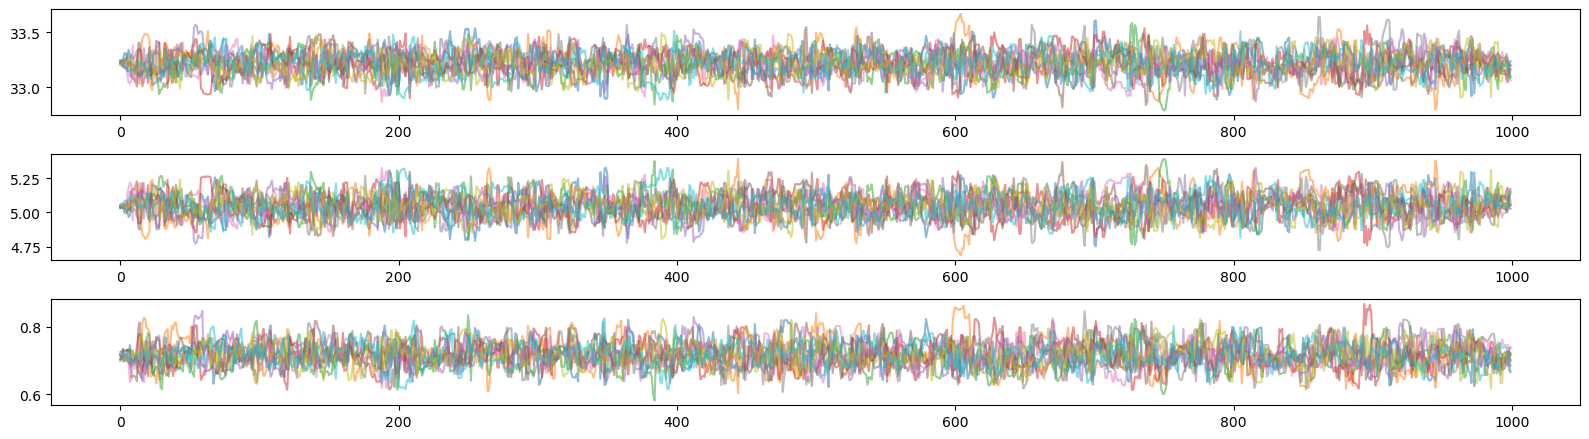

In [10]:
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain()[:,:,n], alpha=0.5)
plt.tight_layout()
#plt.savefig(path)
plt.show()

In [11]:
chain = sampler.get_chain(flat=True, discard=nsteps//4, thin=1)

Removed no burn in


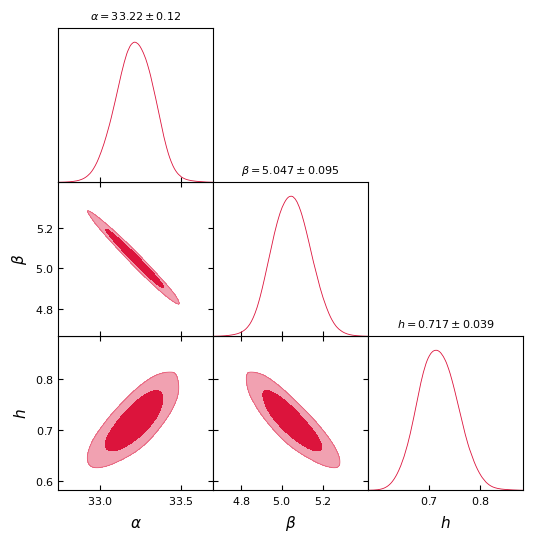

In [14]:
%matplotlib inline
tag = 'GDplot'
GDsamples = MCSamples(samples=chain, names=parameters,
                          labels=parameters, name_tag=tag #,
                          # ranges={r"\Omega_m":[0.0, None]}
                          )

g = plots.getSubplotPlotter() #width_inch=4
g.settings.num_plot_contours = 2
g.triangle_plot(GDsamples, filled=True, title_limit=1,
            contour_colors=['crimson']
            # , param_limits={r"\alpha":[32.8, 33.7]
                        # , r"\beta":[4.7, 5.35]
                        # , r"h":[0.6, 0.85]
                        # , r"\Omega_m":[0.0, 0.52]
                        # , r"w_0":[-2.1, -0.2]
                        # }
            )